<a href="https://colab.research.google.com/github/pandeyp84/Deep-Learning-Tutorials/blob/main/RNN_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANN and CNN

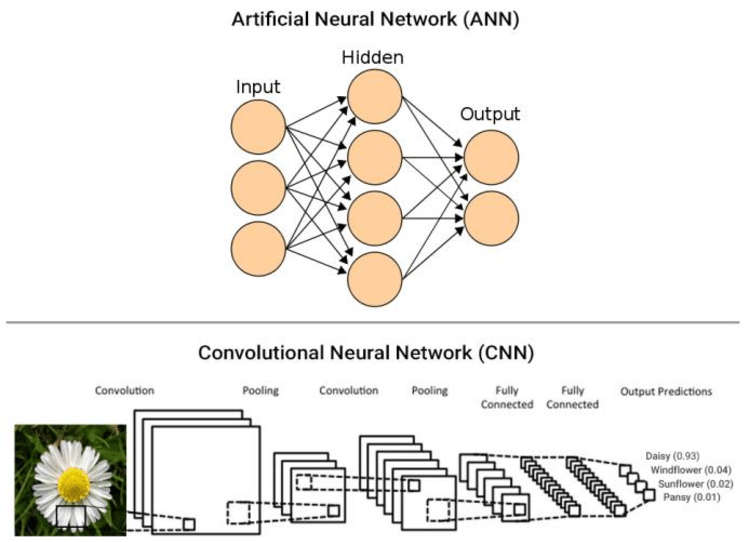



## Why **ANN (Artificial Neural Networks)** are not suitable for temporal data

* **No memory of past inputs**: ANN treats each input independently and cannot remember previous time steps.
* **Ignores sequence order**: Temporal dependencies (what happened before) are not preserved.
* **Poor long-term dependency learning**: Cannot capture trends, seasonality, or delayed effects.




## Why **CNN (Convolutional Neural Networks)** are not suitable for temporal data

* **Designed for spatial data**: CNNs excel at spatial patterns (images), not time dependencies.
* **Limited temporal context**: Convolution filters capture only short, local patterns.
* **No inherent sequential memory**: Past information is not retained beyond the kernel window.
* **Struggles with long-term dependencies**: Cannot model relationships across long time gaps.
* **Order sensitivity is weak**: Temporal order matters, but CNNs are more position-invariant.


#RNN

## Why RNN is Good

* **Has memory**: RNN stores information from previous time steps using a hidden state.
* **Handles sequences naturally**: Designed specifically for time-series and sequential data.
* **Preserves order of data**: Learns patterns based on the order of inputs.
* **Captures temporal dependencies**: Understands how past values influence current outputs.
* **Parameter sharing over time**: Same weights are reused at each time step, improving efficiency.
* **Suitable for real-world sequences**: Speech, text, video frames, sensor data, stock prices.



## Applications of **RNN (Recurrent Neural Network)**

* **Speech recognition** – understanding spoken words
* **Text processing** – text generation, sentiment analysis
* **Language modeling** – next word prediction
* **Time-series prediction** – weather, stock prices
* **Video frame analysis** – action recognition
* **Machine translation** – language-to-language conversion
* **Speech recognition systems** (Alexa, Siri, Google Assistant)
* **Healthcare monitoring** – ECG, patient data analysis
* **Music generation**
* **Chatbots and conversational AI**



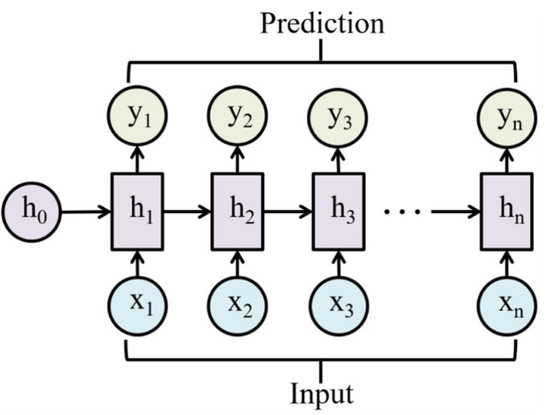

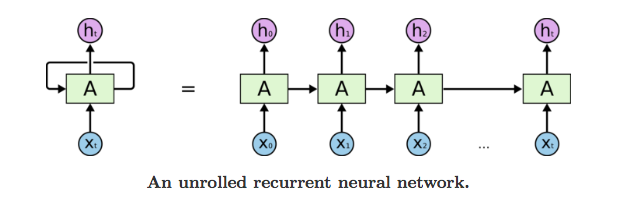


## 1. $(x_t)$ — Input at time *t*

* $(x_t)$ is the **input vector** at time step (t).
* It represents the current element in the sequence.

**Example:**

* In a sentence: $(x_t)$ = embedding of the *t-th word*
* In time series: $(x_t)$ = value at time (t)



## 2. $(h_t)$ — Hidden state at time *t*

* $(h_t)$ is the **memory of the RNN**.
* It stores information from **previous time steps**.
* Computed using current input and previous hidden state:


$h_t$ = f($W_{xh}$ $x_t$ + $W_{hh}$ $h_{t-1}$ + $b_h$)


where (f) is an activation function (tanh/ReLU).



## 3. ($y_t$) — Output at time *t*

* ($y_t$) is the **output** of the RNN at time step (t).
* It is calculated from the hidden state:


$y_t$ = g($W_{hy}$ $h_t$ + $b_y$)


where (g) is usually softmax or linear.



## Simple Flow


$x_t$ $\rightarrow$ $h_t$ $\rightarrow$ $y_t$




## Example (Sentence Prediction)

| Symbol | Meaning                     |
| ------ | --------------------------- |
| ($x_t$)  | Current word                |
| ($h_t$)  | Context from previous words |
| ($y_t$)  | Predicted next word         |



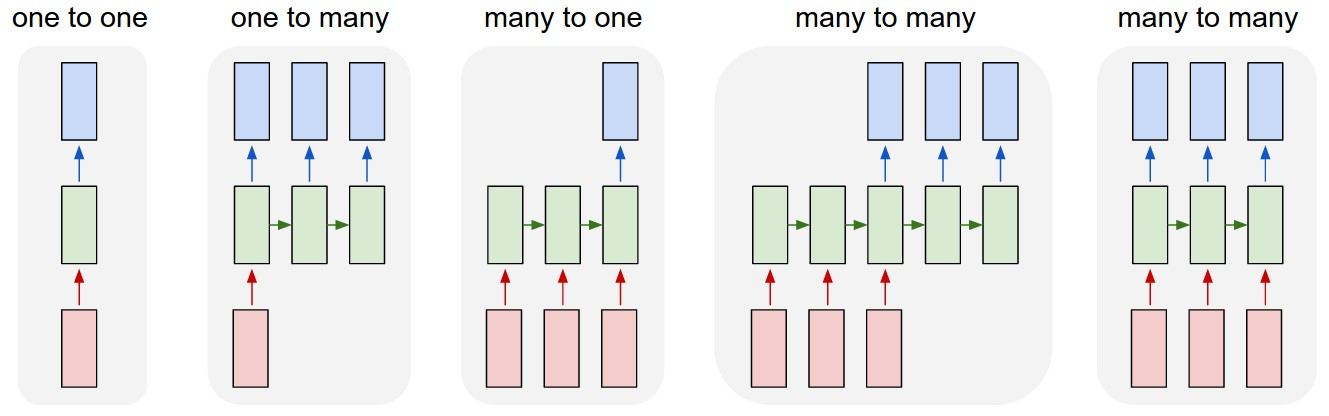



## 1️⃣ One-to-One

**(Single input → Single output)**

**Example:**

* Image → Class label
* Sentiment of a single sentence

📌 *Used in ANN/CNN*



## 2️⃣ One-to-Many

**(Single input → Sequence output)**

**Example:**

* **Image captioning**: Image → sentence
* Music generation: Start note → sequence of notes

📌 RNN generates multiple outputs from one input



## 3️⃣ Many-to-One

**(Sequence input → Single output)**

**Example:**

* **Sentiment analysis**: Sentence → Positive/Negative
* **Spam detection**: Email text → Spam/Not spam
* Activity recognition: Sensor data → Activity label

📌 Final hidden state gives the output



## 4️⃣ Many-to-Many (Same length)

**(Sequence input → Sequence output)**

**Example:**

* **POS tagging**: Sentence → POS tags
* Named Entity Recognition (NER)
* Video frame labeling

📌 Output at every time step

---

## 5️⃣ Many-to-Many (Different length)

**(Sequence input → Sequence output, different sizes)**

**Example:**

* **Machine translation**: English sentence → French sentence
* Speech-to-text
* Text summarization

📌 Uses **Encoder–Decoder **






## Step-by-Step Training of an RNN

### **Step 1: Prepare the sequential data**

* Organize data as sequences (($x_1, x_2, \dots, x_T$)).
* Define target outputs (($y_1, y_2, \dots, y_T$)) or a single output (y).
* Convert inputs to numerical form (e.g., embeddings, normalization).

---

### **Step 2: Initialize parameters**

* Initialize weight matrices:

  * ($W_{xh}$): input → hidden
  * ($W_{hh}$): hidden → hidden
  * ($W_{hy}$): hidden → output
* Initialize biases.
* Set initial hidden state ($h_0$) (usually zeros).

---

### **Step 3: Forward propagation (Unrolling the RNN)**

* Process input **time step by time step**.
* For each time step (t):


$h_t = f(W_{xh}x_t + W_{hh}h_{t-1} + b_h)$



$y_t = g(W_{hy}h_t + b_y)$


* The RNN is “unrolled” across time steps.

---

### **Step 4: Compute the loss**

* Compare predicted output(s) with actual target(s).
* Use a suitable loss function:

  * Cross-entropy (classification)
  * Mean squared error (regression)
* Total loss = sum (or average) of losses over all time steps.

---

### **Step 5: Backpropagation Through Time (BPTT)**

* Backpropagate the error **from the last time step to the first**.
* Compute gradients for all shared weights.
* Accumulate gradients across time steps.

📌 This is called **Backpropagation Through Time (BPTT)**.

---

### **Step 6: Gradient clipping (optional but important)**

* Clip gradients to avoid **exploding gradients**.
* Helps stabilize training.

---

### **Step 7: Update weights**

* Update parameters using an optimizer:

  * SGD
  * Adam
  * RMSProp


$W = W - \eta \frac{\partial L}{\partial W}$


where ($\eta$) is the learning rate.






In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# -----------------------------
# Custom RNN from scratch
# -----------------------------
class ScratchRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(ScratchRNN, self).__init__()

        self.hidden_size = hidden_size

        # Hidden state weights
        self.W_xh = nn.Parameter(torch.randn(input_size, hidden_size) * 0.01)
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        self.b_h = nn.Parameter(torch.zeros(hidden_size))

        # Output layer weights
        self.W_hy = nn.Parameter(torch.randn(hidden_size, output_size) * 0.01)
        self.b_y = nn.Parameter(torch.zeros(output_size))

    def forward(self, x):
        """
        x shape: (batch_size, seq_len, input_size)
        """
        batch_size, seq_len, _ = x.shape

        # Initial hidden state
        h_t = torch.zeros(batch_size, self.hidden_size)

        for t in range(seq_len):
            x_t = x[:, t, :]   # current timestep input

            # Hidden update
            h_t = torch.tanh(x_t @ self.W_xh + h_t @ self.W_hh + self.b_h)

        # Final output from last hidden state
        y = h_t @ self.W_hy + self.b_y

        return y




In [ ]:
# -----------------------------
# Example Usage
# -----------------------------
input_size = 5
hidden_size = 16
output_size = 2
seq_len = 10
batch_size = 4

model = ScratchRNN(input_size, hidden_size, output_size)

# Dummy input
x = torch.randn(batch_size, seq_len, input_size)

# Forward pass
output = model(x)

print("Output Shape:", output.shape)   # (batch_size, output_size)
print(output)


# -----------------------------
# Training Example
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Dummy labels
y_true = torch.tensor([0, 1, 0, 1])

for epoch in range(100):
    optimizer.zero_grad()

    y_pred = model(x)

    loss = criterion(y_pred, y_true)

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Output Shape: torch.Size([4, 2])
tensor([[-7.8319e-04,  4.9758e-04],
        [ 5.4310e-05, -1.4268e-03],
        [-7.1070e-05,  1.8854e-03],
        [ 3.9882e-04, -1.8484e-04]], grad_fn=<AddBackward0>)
Epoch 0, Loss: 0.6938
Epoch 10, Loss: 0.3597
Epoch 20, Loss: 0.0106
Epoch 30, Loss: 0.0017
Epoch 40, Loss: 0.0008
Epoch 50, Loss: 0.0005
Epoch 60, Loss: 0.0004
Epoch 70, Loss: 0.0004
Epoch 80, Loss: 0.0003
Epoch 90, Loss: 0.0003




## Problem: Temperature Prediction (Time Series Forecasting)

We want to **predict future temperature** based on **past weather measurements** using a **Recurrent Neural Network (RNN)**, specifically an **LSTM**, which is well-suited for time-series data.

---

## Dataset Used: Jena Climate Dataset

**Name:** Jena Climate Dataset
**Source:** Max Planck Institute for Biogeochemistry
**Commonly used in:** Time-series forecasting tutorials

**Description:**

* Recorded every **10 minutes**
* Weather data from **2009–2016**
* Features include:

  * Temperature (°C)
  * Pressure
  * Humidity
  * Wind speed

We will **predict future temperature** using **past temperature values only** (univariate time series).





In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
!wget https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip


--2026-04-19 05:40:14--  https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.2.207, 74.125.137.207, 142.250.101.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.2.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13568290 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  69.1MB/s    in 0.2s    

2026-04-19 05:40:14 (69.1 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13568290/13568290]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  


In [ ]:
df = pd.read_csv('jena_climate_2009_2016.csv')
temperature = df['T (degC)'].values.reshape(-1, 1)

scaler = MinMaxScaler()
temperature_scaled = scaler.fit_transform(temperature)


We use the **past 24 hours** (144 data points, since 10-min intervals) to predict the **next temperature**. (Sliding Window)




**Explanation:**

* `X`: past temperature values (input)
* `y`: next temperature value (target)

In [ ]:
def create_sequences(data, time_steps=144):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)

X, y = create_sequences(temperature_scaled)

In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]




#  What Inputs Does an RNN Take?

### 🔹 RNN Input Shape

```text
(batch_size, time_steps, features)
```

### In our example:

```python
input_shape = (144, 1)
```

| Dimension      | Meaning                                                      |
| -------------- | ------------------------------------------------------------ |
| **batch_size** | Number of samples processed together (handled automatically) |
| **time_steps** | Number of past time points (144 = 24 hours)                  |
| **features**   | Number of features at each time step (1 = temperature only)  |

---

## 🔹 Example Input to RNN

```text
[
  [15.2],
  [15.3],
  [15.4],
  ...
  [16.1]
]
```

Each value is fed **one step at a time** into the RNN.

---

## 🔹 What Happens Inside RNN?

At each time step `t`:

```text
h_t = tanh(Wx * x_t + Wh * h_(t-1) + b)
```

Where:

* `x_t` → current input
* `h_(t-1)` → previous hidden state (memory)
* `h_t` → current hidden state

This is why RNNs are good for **sequential data**.

---

## 🔹 Important RNN Parameters Explained

```python
SimpleRNN(
    units=50,
    activation="tanh",
    return_sequences=False,
    input_shape=(144, 1)
)
```

| Parameter          | Meaning                             |
| ------------------ | ----------------------------------- |
| `units`            | Number of neurons (memory size)     |
| `activation`       | Non-linearity (`tanh` is default)   |
| `return_sequences` | Return full sequence or last output |
| `input_shape`      | Shape of time series data           |

---

## 🔹 When Do We Use `return_sequences=True`?

```python
SimpleRNN(50, return_sequences=True)
```

Used when:

* Stacking multiple RNN layers
* Many-to-many problems (e.g., predicting temperature for each time step)




In [ ]:
class SimpleRNNModel(nn.Module):
    def __init__(self):
        super(SimpleRNNModel, self).__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=50, batch_first=True)
        self.fc = nn.Linear(50, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

model = SimpleRNNModel().to('cuda')
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

SimpleRNNModel(
  (rnn): RNN(1, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

dataset = TensorDataset(X_train_tensor, y_train_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

history = []

for epoch in range(5):
    epoch_loss = 0
    model.train()

    for batch_x, batch_y in loader:
        optimizer.zero_grad()

        outputs = model(batch_x.to('cuda'))
        loss = criterion(outputs, batch_y.to('cuda'))

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    history.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 0.0004
Epoch 2, Loss: 0.0000
Epoch 3, Loss: 0.0000
Epoch 4, Loss: 0.0000


In [ ]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor.to(device)).numpy()

predicted_temp = scaler.inverse_transform(predictions)
actual_temp = scaler.inverse_transform(y_test)

plt.figure(figsize=(12, 5))
plt.plot(actual_temp[:200], label="Actual")
plt.plot(predicted_temp[:200], label="Predicted")
plt.legend()
plt.title("Temperature Prediction using Simple RNN")
plt.show()



#  Multivariate Temperature Prediction using **Simple RNN**

**Goal:**
Predict **future temperature** using **multiple weather features** (not just temperature).

---

## 📊 Dataset Used: Jena Climate

**Input features used:**

1. Temperature – `T (degC)`
2. Air Pressure – `p (mbar)`
3. Humidity – `rh (%)`
4. Wind Speed – `wv (m/s)`

**Output:**

* Future **temperature**





In [ ]:
!wget https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip


In [ ]:
data = df[['T (degC)','p (mbar)','rh (%)','wv (m/s)']].values
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [ ]:
def create_sequences(data, time_steps=144):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps, :])   # ALL features
        y.append(data[i+time_steps, 0])     # Temperature only
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled)

In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(X_train.shape)

In [ ]:
class MultiRNNModel(nn.Module):
    def __init__(self):
        super(MultiRNNModel, self).__init__()
        self.rnn = nn.RNN(input_size=X_train.shape[2], hidden_size=50, batch_first=True)
        self.fc = nn.Linear(50, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

model = MultiRNNModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)

dataset = TensorDataset(X_train_tensor, y_train_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

for epoch in range(10):
    epoch_loss = 0
    model.train()

    for batch_x, batch_y in loader:
        optimizer.zero_grad()

        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {epoch_loss/len(loader):.4f}")

In [ ]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor).numpy()

# Only inverse-transform temperature column
temp_min = scaler.data_min_[0]
temp_max = scaler.data_max_[0]

predicted_temp = predictions * (temp_max - temp_min) + temp_min
actual_temp = y_test.reshape(-1,1) * (temp_max - temp_min) + temp_min

plt.figure(figsize=(12,5))
plt.plot(actual_temp[:200], label="Actual")
plt.plot(predicted_temp[:200], label="Predicted")
plt.legend()
plt.title("Multivariate Temperature Prediction (Simple RNN)")
plt.show()

#  How Multivariate RNN Input Works

## 🔹 Input Shape

```text
(batch_size, time_steps, features)
```

### In this model:

```python
(?, 144, 4)
```

| Dimension    | Meaning                          |
| ------------ | -------------------------------- |
| `batch_size` | Number of samples per batch      |
| `time_steps` | Past observations (144 = 24 hrs) |
| `features`   | Weather variables (4 features)   |

---

## 🔹 One Time Step Input Example

At **one time step**, input looks like:

```text
[x1, x2, x3, x4]
```

Where:

* `x1` → Temperature
* `x2` → Pressure
* `x3` → Humidity
* `x4` → Wind speed




#Question

## 📈 Dataset for Stock Market Prediction

### **Dataset Source**

**Yahoo Finance – Apple Inc. (AAPL) Stock Data**

### **Time Period**

January 2018 – December 2023 (daily data)

### **Dataset Features**

| Column Name | Description                |
| ----------- | -------------------------- |
| Date        | Trading date               |
| Open        | Opening price of the stock |
| High        | Highest price of the day   |
| Low         | Lowest price of the day    |
| Close       | Closing price of the stock |
| Volume      | Number of shares traded    |

---

##  How to Obtain the Dataset

Download the dataset using:

* **Yahoo Finance website**, or
* **Python (yfinance library)**

```python
import yfinance as yf

data = yf.download("AAPL", start="2018-01-01", end="2024-01-01")
data.to_csv("AAPL_stock.csv")
```

---

##  Task

### **Task 1: Univariate Stock Price Prediction**

* Use **only the `Close` price** column
* Analyze historical trends
* Build a time-series prediction model
* Predict the **next day closing price**



### **Task 2: Multivariate Stock Price Prediction**

* Use **multiple features**:

  * Open
  * High
  * Low
  * Close
  * Volume
* Analyze the relationship between features
* Build a multivariate prediction model
* Predict the **next day closing price**


